In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv("globalwebtraffic.csv")

In [2]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   global_rank             1500 non-null   int64  
 1   domain                  1500 non-null   object 
 2   category                1500 non-null   object 
 3   primary_market          1500 non-null   object 
 4   monthly_visits          1500 non-null   int64  
 5   bounce_rate_pct         1500 non-null   float64
 6   avg_session_duration_s  1500 non-null   float64
 7   stickiness_index        1500 non-null   float64
 8   last_crawled            1500 non-null   object 
dtypes: float64(3), int64(2), object(4)
memory usage: 105.6+ KB


,global_rank,domain,category,primary_market,monthly_visits,bounce_rate_pct,avg_session_duration_s,stickiness_index,last_crawled
count,1500.000000,1500,1500,1500,1.500000e+03,1500.000000,1500.000000,1500.000000,1500
unique,NaN,1500,7,6,NaN,NaN,NaN,NaN,1
top,NaN,google.com,Search,JP,NaN,NaN,NaN,NaN,2026-02-07
freq,NaN,1,243,265,NaN,NaN,NaN,NaN,1500
mean,750.500000,NaN,NaN,NaN,5.050741e+07,41.882413,475.505293,25.988400,NaN
std,433.157015,NaN,NaN,NaN,5.111033e+07,10.822619,474.448728,40.033884,NaN
min,1.000000,NaN,NaN,NaN,2.093051e+07,15.010000,60.760000,2.180000,NaN
25%,375.750000,NaN,NaN,NaN,3.020608e+07,35.290000,179.682500,7.040000,NaN
50%,750.500000,NaN,NaN,NaN,3.684889e+07,42.695000,343.315000,12.320000,NaN
75%,1125.250000,NaN,NaN,NaN,5.180578e+07,50.100000,521.490000,19.645000,NaN


In [3]:
df.isnull().sum()
#Non-null data

global_rank               0
domain                    0
category                  0
primary_market            0
monthly_visits            0
bounce_rate_pct           0
avg_session_duration_s    0
stickiness_index          0
last_crawled              0
dtype: int64

In [4]:
df.duplicated().sum()
#no duplicates

np.int64(0)

In [5]:
df.dtypes


global_rank                 int64
domain                     object
category                   object
primary_market             object
monthly_visits              int64
bounce_rate_pct           float64
avg_session_duration_s    float64
stickiness_index          float64
last_crawled               object
dtype: object

In [6]:
df['last_crawled'] = pd.to_datetime(df['last_crawled'])

# category
df['category'] = df['category'].astype('category')
df['primary_market'] = df['primary_market'].astype('category')

# float
df['bounce_rate_pct'] = df['bounce_rate_pct'].astype('float32')
df['avg_session_duration_s'] = df['avg_session_duration_s'].astype('float32')
df['stickiness_index'] = df['stickiness_index'].astype('float32')


In [9]:
df['engagement_score'] = (
    (1 - df['bounce_rate_pct']/100) * 0.4 +
    (df['avg_session_duration_s']/df['avg_session_duration_s'].max()) * 0.4 +
    (df['stickiness_index']/df['stickiness_index'].max()) * 0.2
)


In [10]:
df['log_monthly_visits'] = np.log1p(df['monthly_visits'])


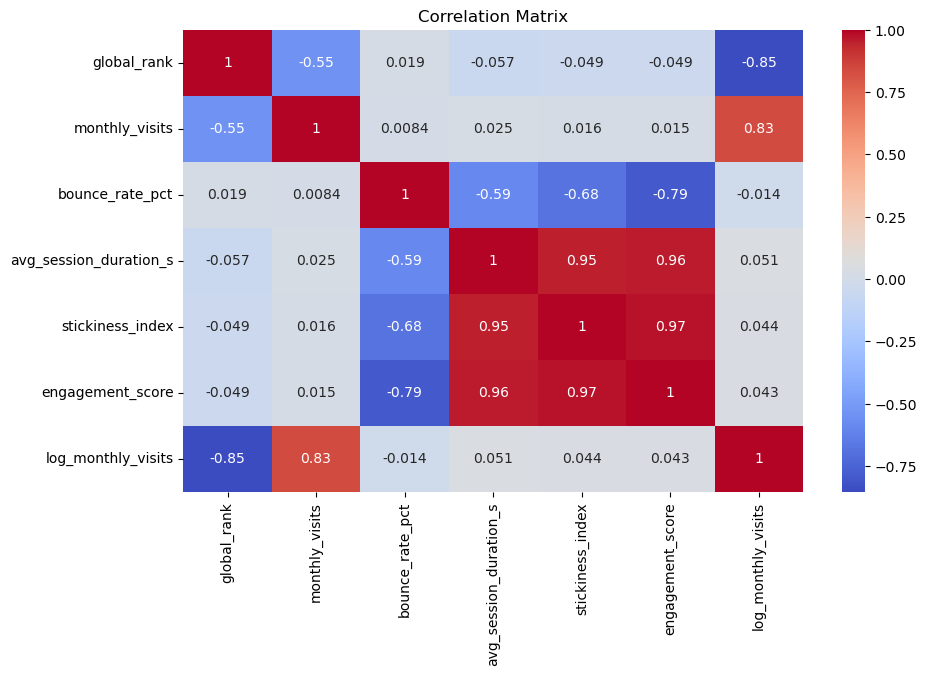

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [12]:
# There is almost perfect positive correlation between Engagement score, Stickiness index, and Avg session duration (which is 0.95 to 0.97).
# These three metrics describe how if a user stays longer with high "avg_session_duration_s", they are almost guaranteed to have a high stickiness_index.
#Bounce Rate & Engagement Score.
#Global Rank & Monthly Visits. just because a site has high traffic (monthly_visits) doesn't mean those users are engaging deeply.

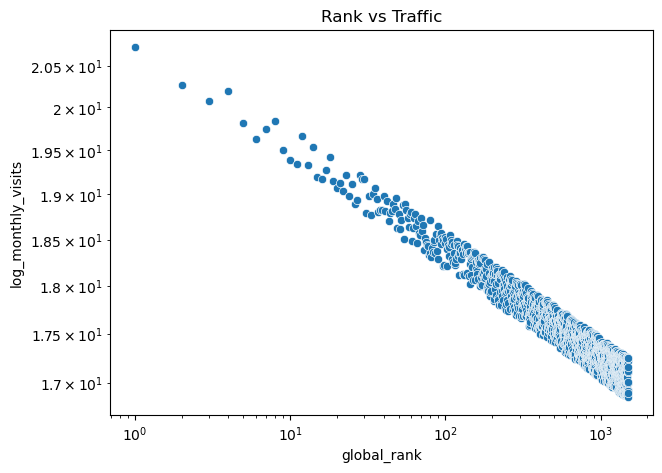

In [13]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='global_rank', y='log_monthly_visits', data=df)
plt.yscale('log')
plt.xscale('log')
plt.title("Rank vs Traffic")
plt.show()


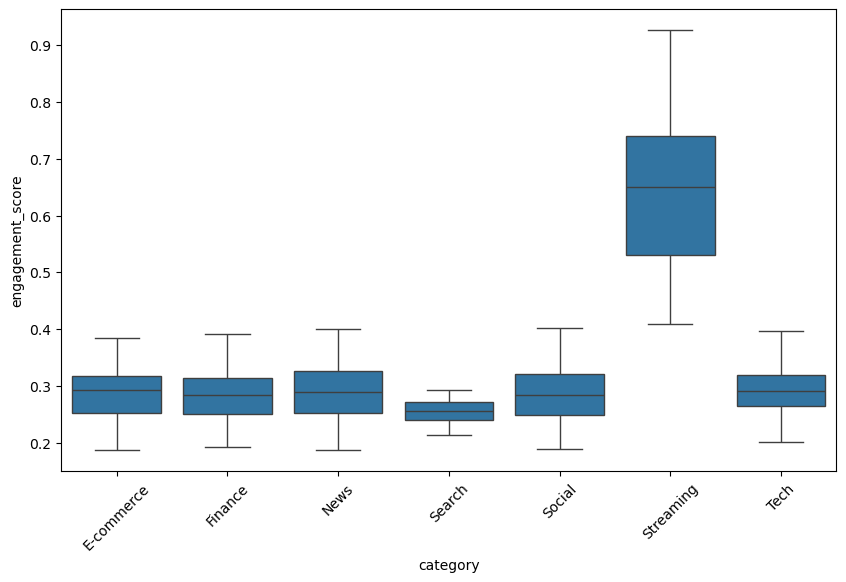

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(x='category', y='engagement_score', data=df)
plt.xticks(rotation=45)
plt.show()

In [15]:
df.groupby('primary_market', observed=True)[['monthly_visits', 'engagement_score']].mean().sort_values(by='monthly_visits', ascending=False)

,monthly_visits,engagement_score
primary_market,,
IN,5.354026e+07,0.338899
DE,5.234512e+07,0.312914
GB,5.103079e+07,0.334487
BR,5.099339e+07,0.339941
US,4.812503e+07,0.328645
JP,4.756045e+07,0.337827


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = df[['log_monthly_visits',
               'bounce_rate_pct',
               'avg_session_duration_s',
               'stickiness_index']]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

df['pca1'] = pca_result[:,0]
df['pca2'] = pca_result[:,1]


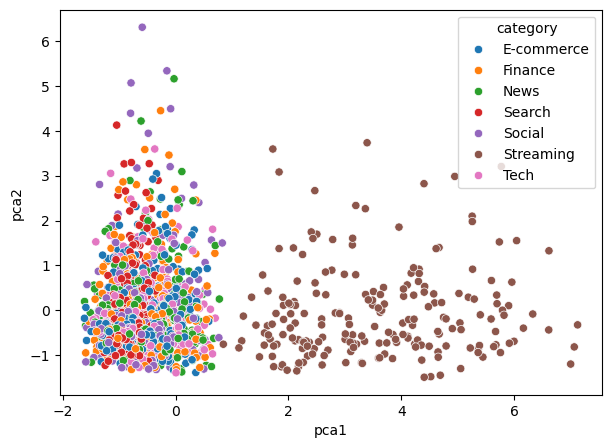

In [17]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='pca1', y='pca2', hue='category', data=df)
plt.show()


In [18]:
# Streaming websites don't just have higher scores but their entire "combination of rank, visits, duration, and stickiness" is different from every other category.
# Those scattered dots (Social in purple and News in green) that are shooting upward along the pca2 axis are known as outliers. 